In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors


In [18]:
# Read matmul results
def read_data(file_name):

    data = pd.read_csv(file_name, 
                            delimiter=",",
                            skiprows=0)

    # Calculate total GPU time
    data['total_gpu_time_ms'] = (data['H2D_time_ms'] + 
                                        data['kernel_time_ms'] + 
                                        data['D2H_time_ms'])

    # Get unique matrix sizes and threads per block values
    matrix_sizes = sorted(data['matrix_size'].unique())
    threads_per_block = sorted(data['threads_per_block'].unique())

    print(f"Matrix sizes: {matrix_sizes}")
    print(f"Threads per block: {threads_per_block}")

    return data, matrix_sizes, threads_per_block

# Create 2D matrix for colorplot
# Rows: matrix sizes, Columns: threads per block
def create_heatmap_data(threads_data, matrix_sizes, threads_per_block):

    heatmap_data = np.zeros((len(matrix_sizes), len(threads_per_block)))

    for i, size in enumerate(matrix_sizes):
        for j, threads in enumerate(threads_per_block):
            subset = threads_data[(threads_data['matrix_size'] == size) & 
                                (threads_data['threads_per_block'] == threads)]
            if not subset.empty:
                heatmap_data[i, j] = subset['total_gpu_time_ms'].values[0]
            else:
                heatmap_data[i, j] = np.nan
    return heatmap_data

In [24]:

matmul_data, _, _ = read_data("matmul_results.txt")


Matrix sizes: [4096, 16384, 65536, 262144, 1048576, 2359296, 4194304, 6553600, 9437184, 16777216]
Threads per block: [32]


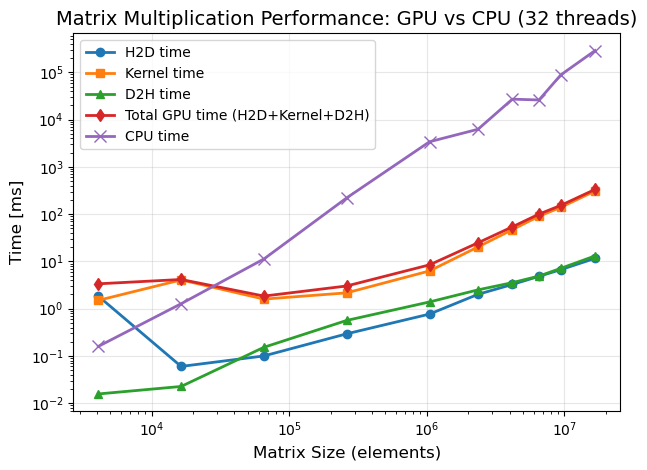

In [92]:
plt.plot(matmul_data['matrix_size'], matmul_data['H2D_time_ms'], 
         'o-', label='H2D time', linewidth=2, markersize=6)
plt.plot(matmul_data['matrix_size'], matmul_data['kernel_time_ms'], 
         's-', label='Kernel time', linewidth=2, markersize=6)
plt.plot(matmul_data['matrix_size'], matmul_data['D2H_time_ms'], 
         '^-', label='D2H time', linewidth=2, markersize=6)
plt.plot(matmul_data['matrix_size'], matmul_data['total_gpu_time_ms'], 
         'd-', label='Total GPU time (H2D+Kernel+D2H)', linewidth=2, markersize=6)
plt.plot(matmul_data['matrix_size'], matmul_data['CPU_time_ms'], 
         'x-', label='CPU time', linewidth=2, markersize=8)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Matrix Size (elements)', fontsize=12)
plt.ylabel('Time [ms]', fontsize=12)
plt.title('Matrix Multiplication Performance: GPU vs CPU (32 threads)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance.pdf', dpi=300, bbox_inches='tight')
plt.show()


max speedup w data movement:  865.4844651686557
max speedup calculation:  934.6195969980002


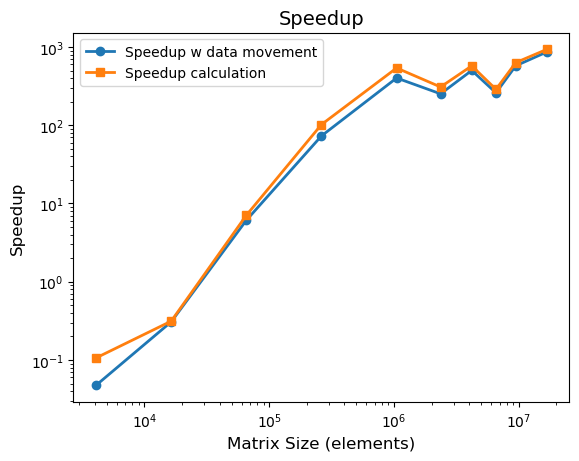

In [101]:
speedup_tot = matmul_data['CPU_time_ms'] / matmul_data['total_gpu_time_ms']
speedup_calculation = matmul_data['CPU_time_ms'] / matmul_data['kernel_time_ms']
plt.plot(matmul_data['matrix_size'], speedup_tot, 
         'o-', label='Speedup w data movement', linewidth=2, markersize=6)
plt.plot(matmul_data['matrix_size'], speedup_calculation, 
         's-', label='Speedup calculation', linewidth=2, markersize=6)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Speedup', fontsize=12)
plt.xlabel('Matrix Size (elements)', fontsize=12)
plt.title('Speedup', fontsize=14)
plt.savefig('speedup.pdf', dpi=300, bbox_inches='tight')
plt.legend(fontsize=10)

print('max speedup w data movement: ', max(speedup_tot))
print('max speedup calculation: ', max(speedup_calculation))


In [70]:
threads_data, matrix_sizes, threads_per_block = read_data("threads_per_block_results.txt")
heatmap_data = create_heatmap_data(threads_data, matrix_sizes, threads_per_block)


Matrix sizes: [1048576, 2359296, 4194304, 6553600, 9437184, 16777216, 67108864]
Threads per block: [2, 4, 6, 8, 12, 16, 20, 24, 28, 32]


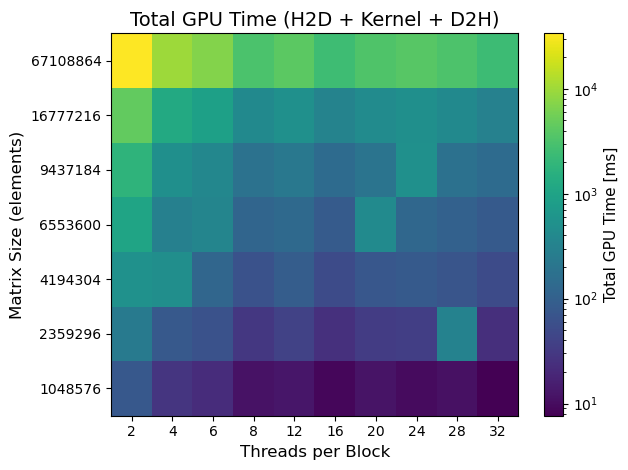

In [84]:
# Set up a LogNorm for log-coloured heatmap; ignore zeros by using `nan` (already handled)

norm = mcolors.LogNorm(vmin=np.nanmin(heatmap_data[heatmap_data > 0]), vmax=np.nanmax(heatmap_data))

# Create the heatmap in log color
im = plt.imshow(heatmap_data, aspect='auto', cmap='viridis', origin='lower', norm=norm)

# Set ticks and labels
plt.xticks(range(len(threads_per_block)), threads_per_block)
plt.yticks(range(len(matrix_sizes)), matrix_sizes)

# Labels
plt.xlabel('Threads per Block', fontsize=12)
plt.ylabel('Matrix Size (elements)', fontsize=12)
plt.title('Total GPU Time (H2D + Kernel + D2H)', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Total GPU Time [ms]', fontsize=11)
    

plt.tight_layout()
plt.savefig('threads_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()


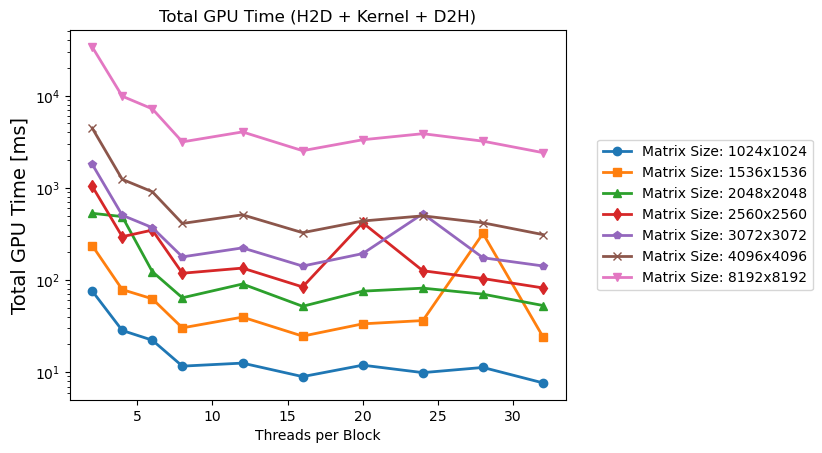

In [99]:
markers = ['o-', 's-', '^-', 'd-', 'p-', 'x-', 'v-', '<-', '>-', 'h-']  # use as many as needed, repeat if more lines
for i in range(len(matrix_sizes)):
    style = markers[i % len(markers)]
    plt.plot(
        threads_per_block,
        heatmap_data[i, :],
        style,
        label=f'Matrix Size: {int(np.sqrt(matrix_sizes[i]))}x{int(np.sqrt(matrix_sizes[i]))}',
        linewidth=2,
        markersize=6
    )
plt.yscale('log')
plt.title('Total GPU Time (H2D + Kernel + D2H)')
plt.xlabel('Threads per Block')
plt.ylabel('Total GPU Time [ms]', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.savefig('threads.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [59]:
threads_data_sh, matrix_sizes_sh, threads_per_block_sh = read_data("threads_per_block_shared_results.txt")
heatmap_data_sh = create_heatmap_data(threads_data_sh, matrix_sizes_sh, threads_per_block_sh)


Matrix sizes: [1048576, 2359296, 4194304, 6553600, 9437184, 16777216, 67108864]
Threads per block: [2, 4, 6, 8, 12, 16, 20, 24, 28, 32]


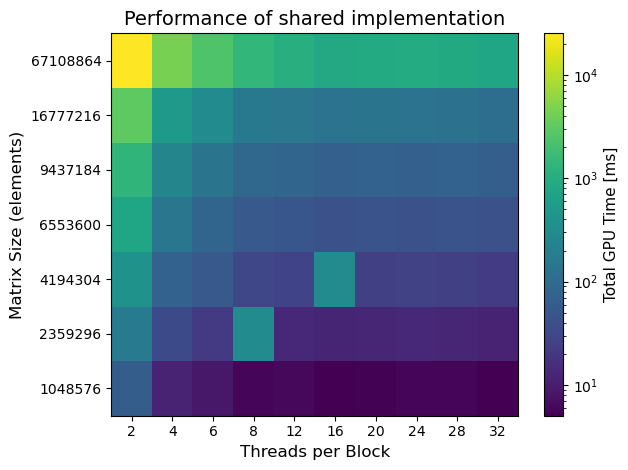

In [98]:

# Set up a LogNorm for log-coloured heatmap; ignore zeros by using `nan` (already handled)
norm = mcolors.LogNorm(vmin=np.nanmin(heatmap_data_sh[heatmap_data_sh > 0]), vmax=np.nanmax(heatmap_data_sh))

# Create the heatmap in log color
im = plt.imshow(heatmap_data_sh, aspect='auto', cmap='viridis', origin='lower', norm=norm)

# Set ticks and labels
plt.xticks(range(len(threads_per_block_sh)), threads_per_block_sh)
plt.yticks(range(len(matrix_sizes_sh)), matrix_sizes_sh)

# Labels
plt.xlabel('Threads per Block', fontsize=12)
plt.ylabel('Matrix Size (elements)', fontsize=12)
plt.title('Performance of shared implementation', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Total GPU Time [ms]', fontsize=11)
    

plt.tight_layout()
plt.savefig('threads_shared_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

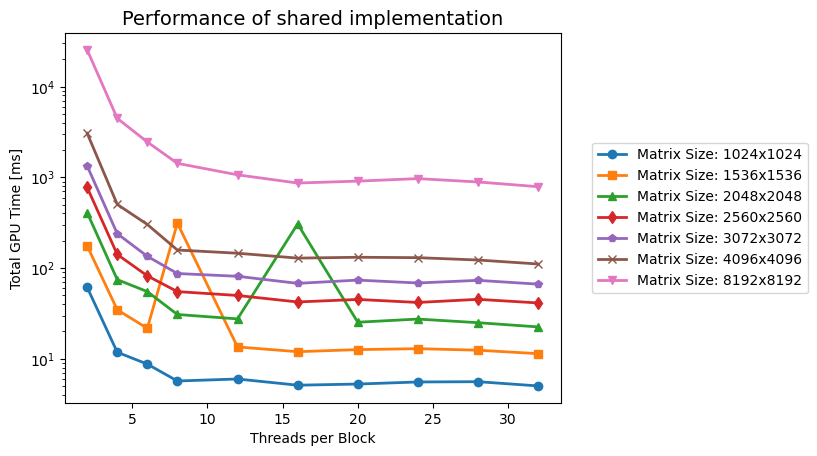

In [100]:
markers = ['o-', 's-', '^-', 'd-', 'p-', 'x-', 'v-', '<-', '>-', 'h-'] # use as many as needed, repeat if more lines
for i in range(len(matrix_sizes_sh)):
    style = markers[i % len(markers)]
    plt.plot(threads_per_block_sh, heatmap_data_sh[i, :], style, label=f'Matrix Size: {int(np.sqrt(matrix_sizes_sh[i]))}x{int(np.sqrt(matrix_sizes_sh[i]))}', linewidth=2, markersize=6)
plt.yscale('log')
plt.title('Performance of shared implementation', fontsize=14)
plt.xlabel('Threads per Block')
plt.ylabel('Total GPU Time [ms]')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.savefig('threads_shared.pdf', dpi=300, bbox_inches='tight')
plt.show()

Matrix sizes: [4096, 16384, 65536, 262144, 1048576, 2359296, 4194304, 6553600, 9437184, 16777216]
Threads per block: [32]


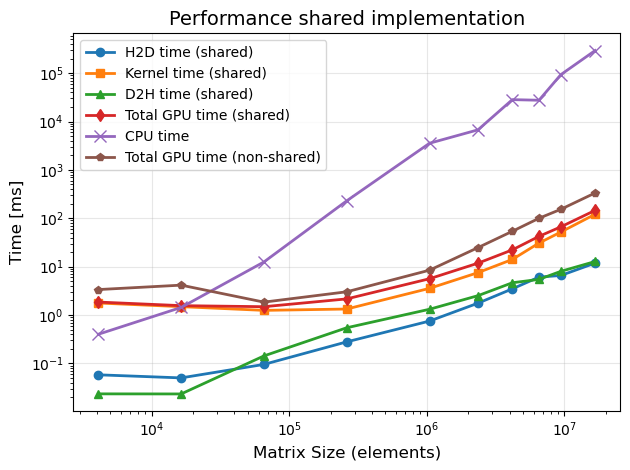

In [96]:
matmul_data_sh, _, _ = read_data("matmul_shared_results.txt")

plt.plot(matmul_data_sh['matrix_size'], matmul_data_sh['H2D_time_ms'], 
         'o-', label='H2D time (shared)', linewidth=2, markersize=6)
plt.plot(matmul_data_sh['matrix_size'], matmul_data_sh['kernel_time_ms'], 
         's-', label='Kernel time (shared)', linewidth=2, markersize=6)
plt.plot(matmul_data_sh['matrix_size'], matmul_data_sh['D2H_time_ms'], 
         '^-', label='D2H time (shared)', linewidth=2, markersize=6)
plt.plot(matmul_data_sh['matrix_size'], matmul_data_sh['total_gpu_time_ms'], 
         'd-', label='Total GPU time (shared)', linewidth=2, markersize=6)
plt.plot(matmul_data_sh['matrix_size'], matmul_data_sh['CPU_time_ms'], 
         'x-', label='CPU time', linewidth=2, markersize=8)
plt.plot(matmul_data['matrix_size'], matmul_data['total_gpu_time_ms'], 
         'p-', label='Total GPU time (non-shared)', linewidth=2, markersize=6)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Matrix Size (elements)', fontsize=12)
plt.ylabel('Time [ms]', fontsize=12)
plt.title('Performance shared implementation', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_shared.pdf', dpi=300, bbox_inches='tight')
plt.show()


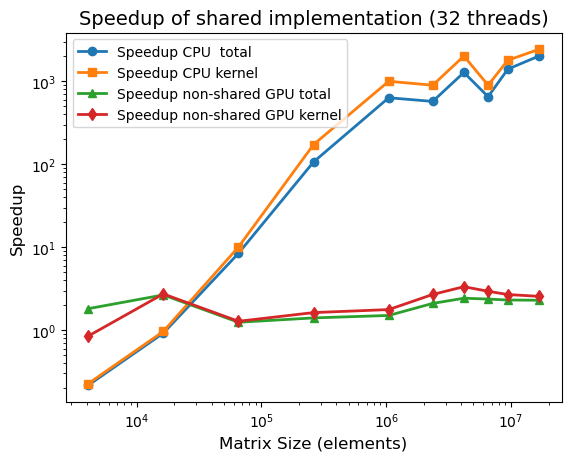

max speedup w data movement:  2013.5414810652267
max speedup calculation:  2422.778171743325
max speedup vs gpu total:  2.6536020905709408
max speedup vs gpu kernel:  3.3353675824331606


In [94]:
speedup_tot = matmul_data_sh['CPU_time_ms'] / matmul_data_sh['total_gpu_time_ms']
speedup_calculation = matmul_data_sh['CPU_time_ms'] / matmul_data_sh['kernel_time_ms']
speedup_gpu = matmul_data['total_gpu_time_ms'] / matmul_data_sh['total_gpu_time_ms']
speedup_gpu_calculation = matmul_data['kernel_time_ms'] / matmul_data_sh['kernel_time_ms']
plt.plot(matmul_data_sh['matrix_size'], speedup_tot, 
         'o-', label='Speedup CPU  total', linewidth=2, markersize=6)
plt.plot(matmul_data_sh['matrix_size'], speedup_calculation, 
         's-', label='Speedup CPU kernel', linewidth=2, markersize=6)
plt.plot(matmul_data['matrix_size'], speedup_gpu, 
         '^-', label='Speedup non-shared GPU total', linewidth=2, markersize=6)
plt.plot(matmul_data['matrix_size'], speedup_gpu_calculation, 
         'd-', label='Speedup non-shared GPU kernel', linewidth=2, markersize=6)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Speedup', fontsize=12)
plt.xlabel('Matrix Size (elements)', fontsize=12)
plt.title('Speedup of shared implementation (32 threads)', fontsize=14)
plt.legend(fontsize=10)
plt.savefig('speedup_shared.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('max speedup w data movement: ', max(speedup_tot))
print('max speedup calculation: ', max(speedup_calculation))
print('max speedup vs gpu total: ', max(speedup_gpu))
print('max speedup vs gpu kernel: ', max(speedup_gpu_calculation))

In [74]:
L1_shared_data, _, _ = read_data("threads_per_block_shared_results_L1.txt")
L1_data, _, _ = read_data("threads_per_block_results_L1.txt")

Matrix sizes: [1048576, 2359296, 4194304, 6553600, 9437184, 16777216, 67108864]
Threads per block: [32]
Matrix sizes: [1048576, 2359296, 4194304, 6553600, 9437184, 16777216, 67108864]
Threads per block: [32]


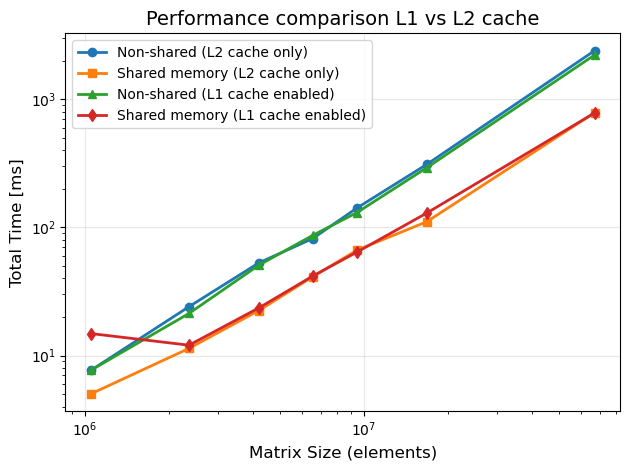

In [93]:
# Filter data for 32 threads from the full datasets
threads_data_32 = threads_data[threads_data['threads_per_block'] == 32].copy()

threads_data_sh_32 = threads_data_sh[threads_data_sh['threads_per_block'] == 32].copy()

# Plot all four datasets for 32 threads
plt.plot(threads_data_32['matrix_size'], threads_data_32['total_gpu_time_ms'], 
         'o-', label='Non-shared (L2 cache only)', linewidth=2, markersize=6)
plt.plot(threads_data_sh_32['matrix_size'], threads_data_sh_32['total_gpu_time_ms'], 
         's-', label='Shared memory (L2 cache only)', linewidth=2, markersize=6)
plt.plot(L1_data['matrix_size'], L1_data['total_gpu_time_ms'], 
         '^-', label='Non-shared (L1 cache enabled)', linewidth=2, markersize=6)
plt.plot(L1_shared_data['matrix_size'], L1_shared_data['total_gpu_time_ms'], 
         'd-', label='Shared memory (L1 cache enabled)', linewidth=2, markersize=6)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Matrix Size (elements)', fontsize=12)
plt.ylabel('Total Time [ms]', fontsize=12)
plt.title('Performance comparison L1 vs L2 cache', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_L1.pdf', dpi=300, bbox_inches='tight')
plt.show()
